<a href="https://colab.research.google.com/github/ramneeth/SCADA_Project/blob/main/scada_portfolio_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SCADA PREDICTIVE MODELLING PORTFOLIO PROJECT

RAMNEET HUNJAN

INTRODUCTION

In this project, I analyze SCADA (Supervisory Control and Data Acquisition) system data to extract insights and evaluate equipment behavior in an industrial setting. SCADA systems are widely used in utilities, manufacturing, and energy sectors to monitor and control physical processes. The goal of this analysis is to:

- Connect to a PostgreSQL database containing real-time SCADA readings

- Explore sensor patterns and correlations

- dentify anomalies or failure indicators

- Build predictive models for equipment performance or failure detection

This portfolio project demonstrates my skills in database integration, exploratory data analysis, and machine learning model development using Python.

DATA OVERVIEW

The dataset is retrieved from a PostgreSQL database and contains time-series sensor data recorded from multiple industrial equipment units. The key variables include:

- equipment_id: Unique identifier for each piece of equipment

- timestamp: Time of data capture

- temperature, pressure, vibration: Sensor readings from each unit

- failure_flag: Binary indicator of equipment failure (1 = failure, 0 = normal)

Each row represents a snapshot of sensor data at a given time. This structure allows us to:

- Perform time-based analysis

- Examine sensor relationships

- Train models for failure prediction or anomaly detection

In [ ]:
import pandas as pd
import psycopg2
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np
from sklearn.metrics import classification_report

DATABASE CONNECTION FROM POSTGESQL

In [ ]:
from sqlalchemy import create_engine
import pandas as pd

# Replace these with your actual values
username = 'postgres'
password = '****'
host = 'localhost'
port = '5432'
database = 'postgres'

# Step 1: Create SQLAlchemy engine
engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

# Step 2: Write your SQL query
query = "SELECT * FROM sensor_readings;"

# Step 3: Use Pandas to read the query using SQLAlchemy
df = pd.read_sql(query, engine)

# Step 4: Preview the data
print(df.head())


  equipment_id           timestamp  temperature  pressure  vibration  \
0         E001 2025-04-27 00:00:00         75.2     250.5      0.020   
1         E002 2025-04-27 00:05:00          NaN     240.0      0.025   
2         E003 2025-04-27 00:10:00        102.4     275.8      0.040   
3         E001 2025-04-27 00:15:00         76.0       NaN      0.021   
4         E002 2025-04-27 00:20:00         81.5     239.5      0.026   

   failure_flag  
0             0  
1             0  
2             1  
3             0  
4             0  


EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
df.describe()

,timestamp,temperature,pressure,vibration,failure_flag
count,10,9.000000,9.000000,9.000000,10.000000
mean,2025-04-27 00:22:30,91.511111,255.922222,0.047000,0.300000
min,2025-04-27 00:00:00,74.800000,238.000000,0.019000,0.000000
25%,2025-04-27 00:11:15,75.900000,240.000000,0.021000,0.000000
50%,2025-04-27 00:22:30,81.500000,250.500000,0.025000,0.000000
75%,2025-04-27 00:33:45,102.400000,275.800000,0.040000,0.750000
max,2025-04-27 00:45:00,150.200000,280.200000,0.200000,1.000000
std,NaN,24.954331,17.236645,0.058316,0.483046


Plot a correlation heatmap to identify which feature may be the most helpful in determining failure of systems.

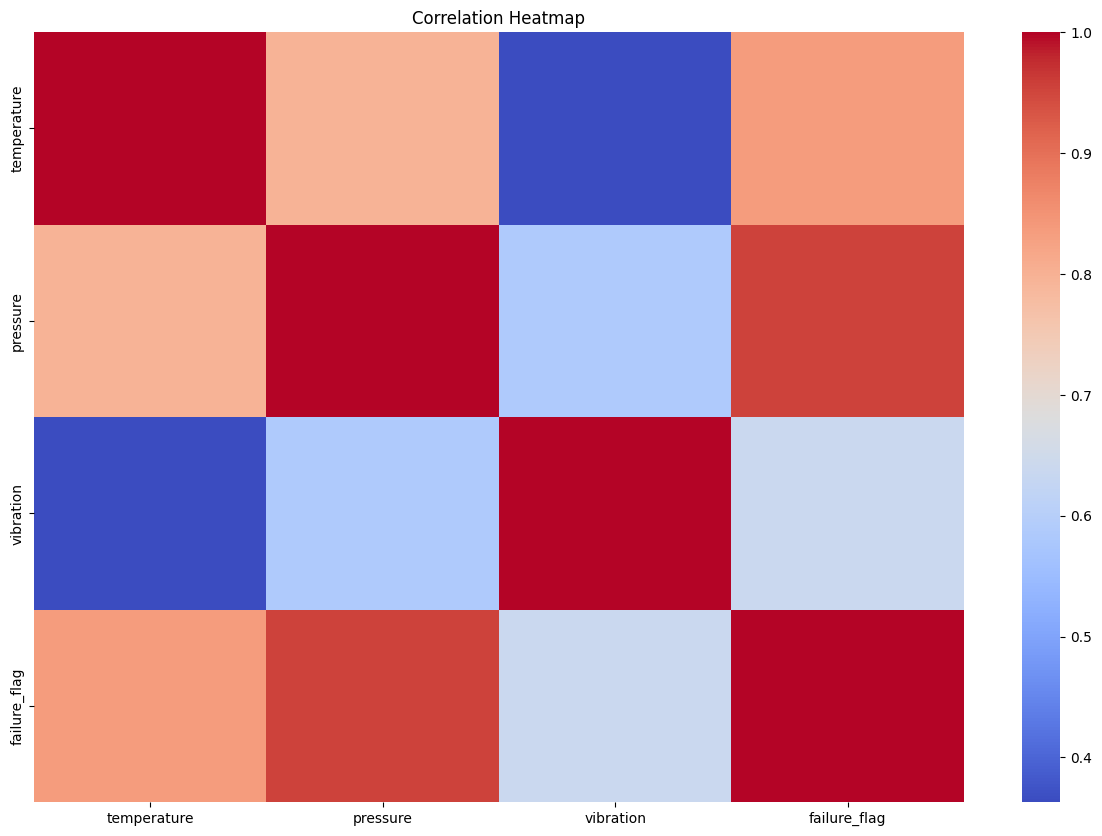

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

Based on the heatmap above, it can be deduced that temperature and pressure seem to be better indicators of failure than vibration.

Now, we determine if there are any missing values in the dataset that need to be filled or possibly even removed.

In [ ]:
#check for missing values
print('Number of Missing Values per Column: \n', df.isnull().sum())

Number of Missing Values per Column: 
 equipment_id    0
timestamp       0
temperature     1
pressure        1
vibration       1
failure_flag    0
dtype: int64


Since we have such a small dataset, each entry matters, so in order to handle missing values, I will employ interpolation and forward fill so we do not lose any rows of information.

In [ ]:
# Impute sensor readings
df[['temperature', 'pressure', 'vibration']] = df[['temperature', 'pressure', 'vibration']].interpolate(method='linear')
df[['temperature', 'pressure', 'vibration']] = df[['temperature', 'pressure', 'vibration']].fillna(method='ffill')


/var/folders/kh/hshjj6b93js296cspgm053ph0000gn/T/ipykernel_10099/797990046.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['temperature', 'pressure', 'vibration']] = df[['temperature', 'pressure', 'vibration']].fillna(method='ffill')


Once the missing values have been filled in, we will double check to make sure there are no more missing values.

In [ ]:
#check for missing values
print('Number of Missing Values per Column: \n', df.isnull().sum())

Number of Missing Values per Column: 
 equipment_id    0
timestamp       0
temperature     0
pressure        0
vibration       0
failure_flag    0
dtype: int64


In [ ]:
df.head()

,equipment_id,timestamp,temperature,pressure,vibration,failure_flag
0,E001,2025-04-27 00:00:00,75.2,250.50,0.020,0
1,E002,2025-04-27 00:05:00,88.8,240.00,0.025,0
2,E003,2025-04-27 00:10:00,102.4,275.80,0.040,1
3,E001,2025-04-27 00:15:00,76.0,257.65,0.021,0
4,E002,2025-04-27 00:20:00,81.5,239.50,0.026,0


Now, we will explore the dataset to identify any outliers in the data.

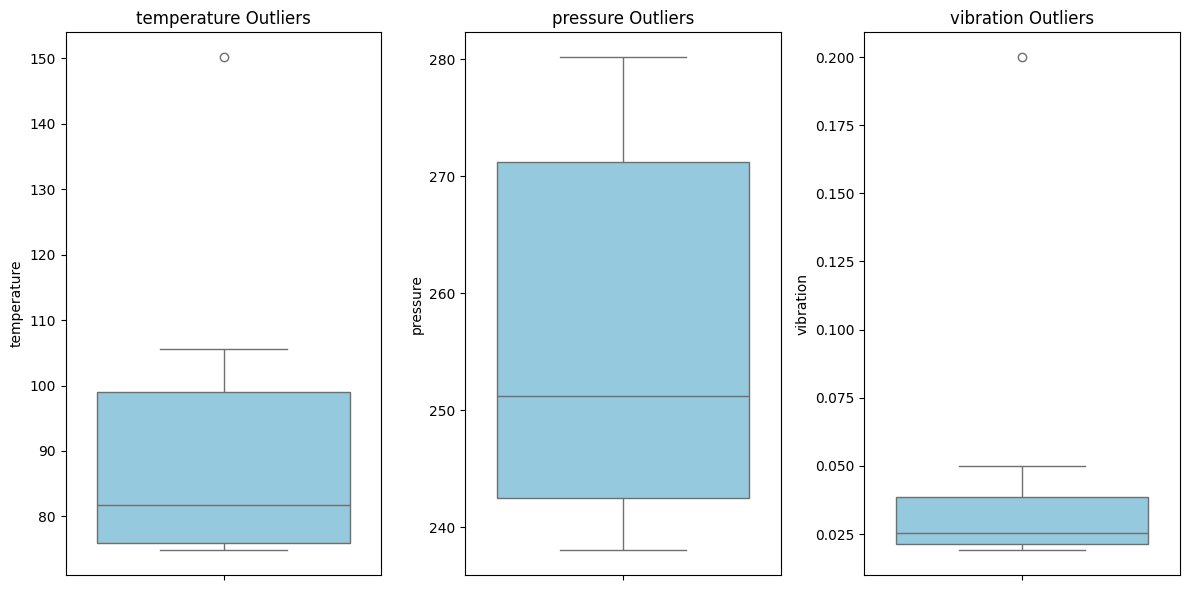

In [ ]:
sensor_cols = ['temperature', 'pressure', 'vibration']

plt.figure(figsize=(12, 6))
for i, col in enumerate(sensor_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col} Outliers')
plt.tight_layout()
plt.show()


The box plot above very clearly identifies outliers in both temperature and vibration.

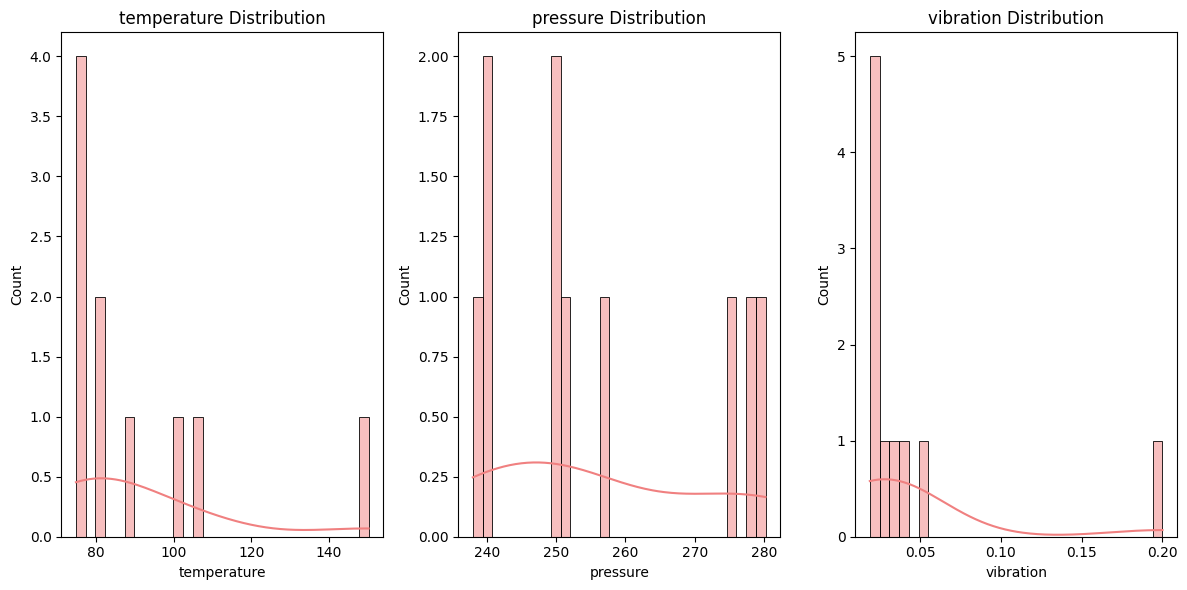

In [ ]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(sensor_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='lightcoral')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()


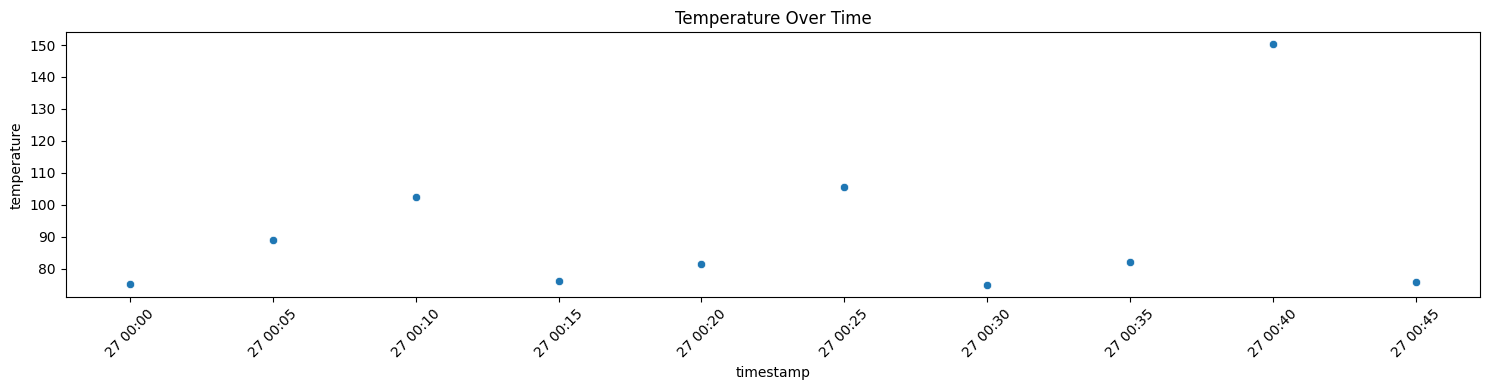

In [ ]:
plt.figure(figsize=(15, 4))
sns.scatterplot(x='timestamp', y='temperature', data=df)
plt.xticks(rotation=45)
plt.title('Temperature Over Time')
plt.tight_layout()
plt.show()


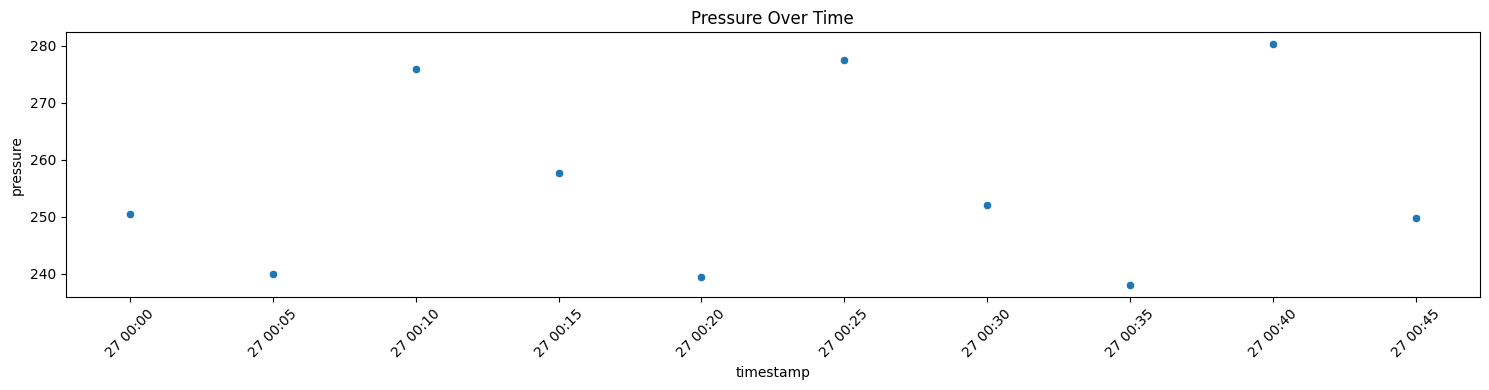

In [ ]:
plt.figure(figsize=(15, 4))
sns.scatterplot(x='timestamp', y='pressure', data=df)
plt.xticks(rotation=45)
plt.title('Pressure Over Time')
plt.tight_layout()
plt.show()


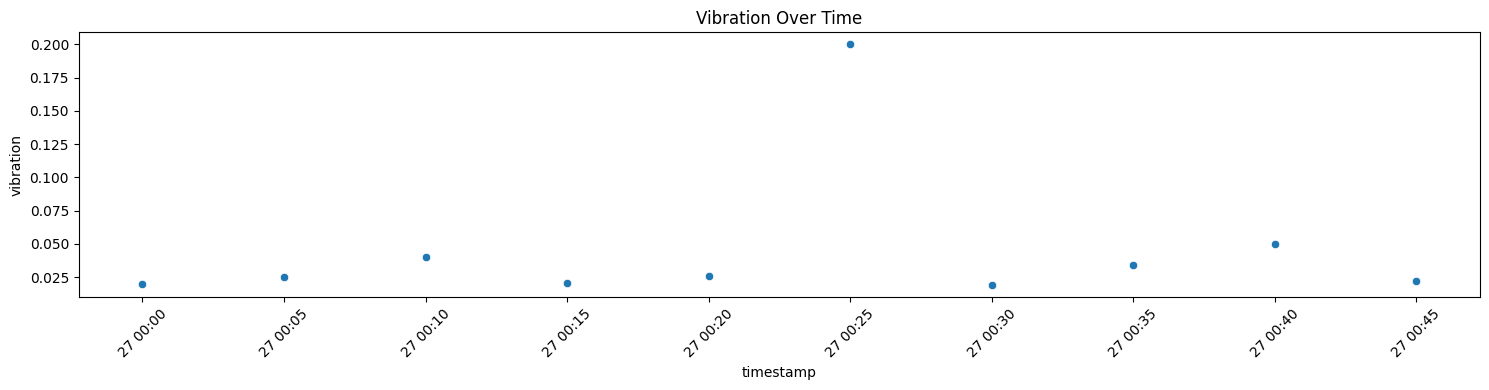

In [ ]:
plt.figure(figsize=(15, 4))
sns.scatterplot(x='timestamp', y='vibration', data=df)
plt.xticks(rotation=45)
plt.title('Vibration Over Time')
plt.tight_layout()
plt.show()


The above histogram plots and scatter plots also confirm that temperature and vibration have outliers. This means that we must remove these outliers to improve the performace of any future model implementations as follows. I chose to use the IQR(Interquartile Range) method to remove outliers. The IQR method removes any points outside the 1st(25%) and 3rd(75%) quartile. This method does not assume anyting about the distribution of the data and is ideal for numerical values like the ones found in this dataset.

In [ ]:
def remove_outliers_iqr(df, columns, factor=1.5):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Apply to your sensor columns
df_clean = remove_outliers_iqr(df, ['temperature', 'vibration'])

print("Shape after removing outliers:", df_clean.shape)


Shape after removing outliers: (8, 6)


MODELING

Now, to begin modeling, we first define out predictive features and our target.

In [ ]:
X = df[['temperature', 'pressure', 'vibration']]

y = df [['failure_flag']]

Then, we split our data into train and test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)



Now, we can train our model. I chose LogisticRegression since we are dealing with a binary classification problem.

In [ ]:
#set up LR model

reg_model = LogisticRegression().fit(X_train, y_train)

/Users/ramneethunjan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


I used the classification_report function from sklearn to show a detailed report of the model's peformance.

In [ ]:
y_pred = reg_model.predict(X_test)

print(classification_report(y_test, y_pred))
#scores = cross_val_score(reg_model, X_train, y_train, cv=2, scoring='r2')
#print("10-Fold CV R²:", scores.mean())

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



/Users/ramneethunjan/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


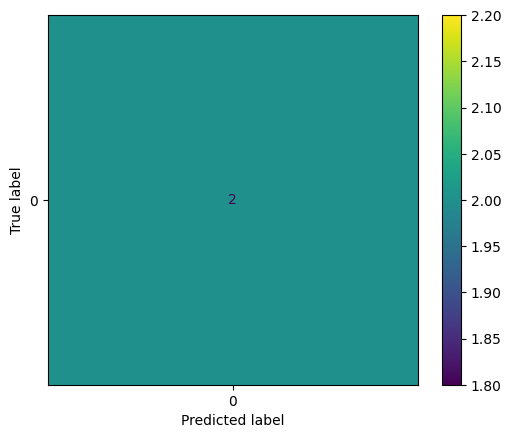

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


Because the dataset is very small and unbalanced, only 8 training rows and 2 test rows, I wasn’t expecting meaningful performance. In fact, my model gave an precision, recall,F1, and accuracy of 1.0, but I know that’s misleading due to the small sample size and test set containing only one class.

For demonstration purposes, I left it this way so I could walk through the pipeline, but in a real-world scenario, I’d definitely expand the dataset, handle class imbalance, and use proper cross-validation.